#Problem 3c#
GitHub Username: rust1966
Repo Link: [Repo Link](https://github.com/rust1966/Markov2026)

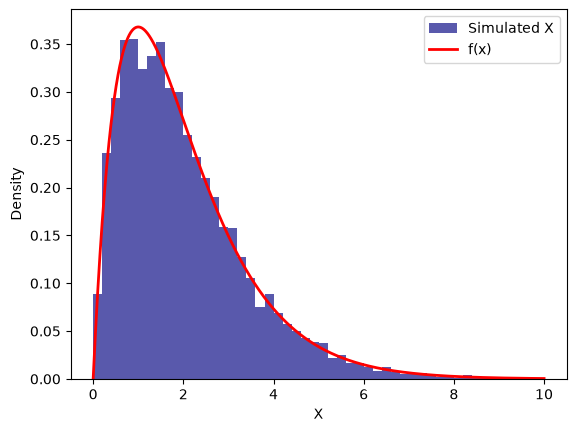

Number of proposals: 14895
Empirical acceptance rate: 0.671366230278617
Theoretical acceptance rate: 0.6795704571147613
Mean time per accepted sample: 3.7582541990559546e-06


In [16]:
import time
import numpy as np
from matplotlib import pyplot as plt

def accept_reject_exp(lambda_, c):
    #Number of accepted samples 
    n = 10 ** 4

    #List to capture returns, attempt count, start time
    x_values = []
    attempts = 0
    start_time = time.perf_counter()

    #Functions defined before method used
    def f(x):
        return x * (np.e ** (-x))

    def g(x):
        return lambda_ * (np.e ** (-lambda_ * x))

    def inverse_g(sample):
        return -(1 / lambda_) * np.log(1 - sample)

    def test_condition(x):
        condition = f(x) / (g(x) * c)
        return condition

    #Actually run test
    while len(x_values) < n:
        u = np.random.uniform(0, 1)
        w = np.random.uniform(0, 1)
        x = inverse_g(w)

        attempts += 1

        if u < test_condition(x):
            x_values.append(x)

    # Calculate elapsed time since we first started:
    elapsed_time = time.perf_counter() - start_time

    #Calculate mean time, theoretial/empirical acc rate:
    emperical_rate = len(x_values) / attempts
    theoretical_rate = 1 / c
    mean_time = elapsed_time / len(x_values)

    plt.hist(x = x_values,
            bins = np.linspace(0, 10, 51),
            density = True,
            color = "navy",
            alpha = 0.65,
            label = "Simulated X")

    x_grid = np.linspace(0, 10, 1000)
    plt.plot(
        x_grid,
        f(x_grid),
        color = "red",
        linewidth = 2,
        label = "f(x)")

    plt.xlabel("X")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

    print("Number of proposals:", attempts)
    print("Empirical acceptance rate:", emperical_rate)
    print("Theoretical acceptance rate:", theoretical_rate)
    print("Mean time per accepted sample:", mean_time)

accept_reject_exp(1/2, 4 / np.e)


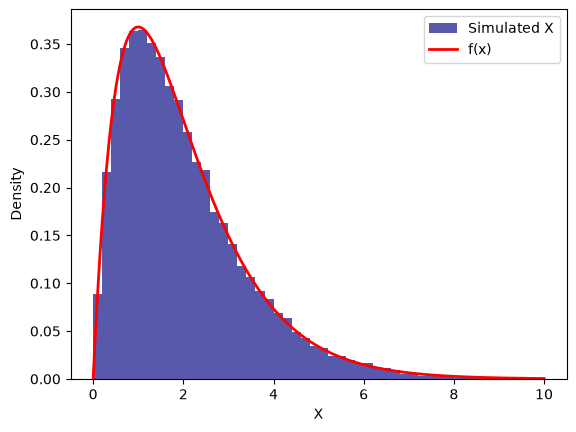

Number of proposals: 23046
Empirical acceptance rate: 0.4339147791373774
Theoretical acceptance rate: 0.4349250925534473
Mean time per accepted sample: 5.613508299575187e-06


In [17]:
#Run the same prcess again except lambda_ = 0.2, c = 1 / (0.16e)
accept_reject_exp(0.2, 1 / (0.16 * np.e))

##Commenting on the difference between the two##

With lambda = 0.2, I got a lower acceptance rate than I did with lambda=0.5, which meant the simulation needed more proposals and took longer per accepted sample. This makes sense because the lambda=0.2 proposal is more spread out and generates more values in the right tail, where the target density is already small. Both histograms still matched the target distribution well, so changing lambda affected the efficiency of the simulation only.